In [ ]:
# Basic libraries
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", DeprecationWarning)
warnings.simplefilter("ignore", FutureWarning)

## Models
from sklearn import tree
from sklearn import ensemble
from sklearn.model_selection import GridSearchCV
from sklearn.manifold import TSNE

## Model Explaination
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

# import linear models and some convenience functions to create dummy data, plot decision boundaries ad split train and test data
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
import sklearn.metrics.pairwise as pairwise
from sklearn.kernel_ridge import KernelRidge

## Metrics
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import r2_score

# Plotting
import graphviz
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# Sklearn
## Data
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# XGBoost
# import xgboost

In [ ]:
# Plotting
import graphviz
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

**Data Acquisition 1**

In [ ]:
#I load the data to see what is in there
features_df = pd.read_csv('TableS6.txt', sep=',', header=0)
print(features_df)



   Molecular descriptor                         Physical–chemical meanings  \
0             Charge 1+                          Charge fraction of plus 1   
1              Charge 0                         Charge fraction of neutral   
2             Charge 1-                         Charge fraction of minus 1   
3           Charge 1+1-                   Fraction of zwitterionic species   
4                LogKow                Octanol/water partition coefficient   
5                LogDow  Octanol/water partition coefficient corrected ...   
6                   pKa                    Acid/base dissociation constant   
7                   Nai                                         Amine type   
8                Log Sw                                 Aqueous solubility   
9                  ExMn                   Exchangeable manganese (cmol/kg)   
10                   MR                                 Molar refractivity   
11                   MW                                   Molecu

In [ ]:
# I renamed columns for clarity
features_df.columns = ['mol_feature', 'mol_meaning', 'solid_feature', 'solid_meaning']

# I extracted the mol features and meaning to rename it, then added a new column called type
mol_df = features_df[['mol_feature', 'mol_meaning']].copy()
mol_df.columns = ['Feature', 'Meaning']
mol_df['Type'] = 'molecular'

# I extracted the solid features as well
solid_df = features_df[['solid_feature', 'solid_meaning']].copy()

#I dropped rows where solid_feature or solid_meaning is NaN
solid_df.dropna(how= 'any', inplace= True)

#I added the cleaned solid to the feature and meaning column, so both mol and solid are under the same column
solid_df.columns = ['Feature', 'Meaning']
solid_df['Type'] = 'solid'

# I concatenate to combine both mol and solid datafreame
combined_df = pd.concat([mol_df, solid_df], ignore_index=True)

# To reset the index of the final combined dataframe
combined_df.reset_index(drop=True, inplace=True)

# Show the result
combined_df

,Feature,Meaning,Type
0,Charge 1+,Charge fraction of plus 1,molecular
1,Charge 0,Charge fraction of neutral,molecular
2,Charge 1-,Charge fraction of minus 1,molecular
3,Charge 1+1-,Fraction of zwitterionic species,molecular
4,LogKow,Octanol/water partition coefficient,molecular
5,LogDow,Octanol/water partition coefficient corrected ...,molecular
6,pKa,Acid/base dissociation constant,molecular
7,Nai,Amine type,molecular
8,Log Sw,Aqueous solubility,molecular
9,ExMn,Exchangeable manganese (cmol/kg),molecular


**Data Acquisition 2**

In [ ]:
#Remove all data for the API’s for which not all sorption coefficients are provided

#I load the data to see what is in it
API_df = pd.read_csv('TableS12.txt', sep=',', header=0)
API_df.groupby(['Pharmaceutical']).count()
API_df

,Pharmaceutical,Log Kd,Charge 1+,Charge 0,Charge 1-,Charge 1+1-,Log Kow,pKa,Nai,Log Sw,...,M LogP,Log Dow,soil_pH,soil_TOC,soil_K,soil_Mg,soil_Na,soil_CEC,soil_Clay,soil_silt
0,Amitriptyline,2.802,99.827,0.173,0.00,0.000,4.79,8.8,1,-4.56,...,4.761,2.19,6.04,4.073,0.2300,2.4957,0.1715,25.110,27,22
1,Amitriptyline,2.824,100.000,0.000,0.00,0.000,4.79,8.8,1,-4.56,...,4.761,1.69,3.19,5.897,0.3000,0.2820,0.0430,4.434,10,22
2,Amitriptyline,2.467,99.969,0.031,0.00,0.000,4.79,8.8,1,-4.56,...,4.761,1.84,5.29,3.225,0.1351,1.1761,0.0593,14.208,29,33
3,Amitriptyline,2.488,99.156,0.844,0.00,0.000,4.79,8.8,1,-4.56,...,4.761,2.75,6.73,3.479,0.4375,0.5576,0.0547,24.282,20,25
4,Amitriptyline,1.925,99.990,0.009,0.00,0.000,4.79,8.8,1,-4.56,...,4.761,1.74,4.76,1.338,0.0770,0.3320,0.0460,4.417,18,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
684,Tetracycline,3.545,61.860,0.000,0.01,38.130,-0.81,9.4,1,-3.06,...,-1.390,-3.54,3.19,5.897,0.3000,0.2820,0.0430,4.434,10,22
685,Tetracycline,3.170,1.272,0.000,2.32,96.408,-0.81,9.4,1,-3.06,...,-1.386,-3.30,5.29,3.225,0.1351,1.1761,0.0593,14.208,29,33
686,Tetracycline,3.055,0.047,0.000,37.59,62.363,-0.81,9.4,1,-3.06,...,-1.386,-3.47,6.73,3.479,0.4375,0.5576,0.0547,24.282,20,25
687,Tetracycline,3.133,4.183,0.000,0.73,95.090,-0.81,9.4,1,-3.06,...,-1.390,-3.30,4.76,1.338,0.0770,0.3320,0.0460,4.417,18,17


In [ ]:
#I import and load the dataset
API_df = pd.read_csv('TableS12.txt', sep=',', header=0)

#Then counted how many times each API appears in the pharmaceutical column
Complete_APIs = API_df["Pharmaceutical"].value_counts()

#This keeps only the API that are 13
Complete_APIs = Complete_APIs[Complete_APIs == 13].index
API_df = API_df[API_df["Pharmaceutical"].isin(Complete_APIs)]

#show result
API_df

,Pharmaceutical,Log Kd,Charge 1+,Charge 0,Charge 1-,Charge 1+1-,Log Kow,pKa,Nai,Log Sw,...,M LogP,Log Dow,soil_pH,soil_TOC,soil_K,soil_Mg,soil_Na,soil_CEC,soil_Clay,soil_silt
0,Amitriptyline,2.802,99.827,0.173,0.000,0.00,4.79,8.8,1,-4.56,...,4.761,2.19,6.04,4.073,0.2300,2.4957,0.1715,25.110,27,22
1,Amitriptyline,2.824,100.000,0.000,0.000,0.00,4.79,8.8,1,-4.56,...,4.761,1.69,3.19,5.897,0.3000,0.2820,0.0430,4.434,10,22
2,Amitriptyline,2.467,99.969,0.031,0.000,0.00,4.79,8.8,1,-4.56,...,4.761,1.84,5.29,3.225,0.1351,1.1761,0.0593,14.208,29,33
3,Amitriptyline,2.488,99.156,0.844,0.000,0.00,4.79,8.8,1,-4.56,...,4.761,2.75,6.73,3.479,0.4375,0.5576,0.0547,24.282,20,25
4,Amitriptyline,1.925,99.990,0.009,0.000,0.00,4.79,8.8,1,-4.56,...,4.761,1.74,4.76,1.338,0.0770,0.3320,0.0460,4.417,18,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678,Pregabalin,-0.022,0.028,0.000,0.045,99.93,-0.92,10.7,3,-0.47,...,1.224,-0.92,7.35,1.434,0.1310,0.5660,0.0980,11.520,14,20
679,Pregabalin,-0.002,0.023,0.000,0.054,99.92,-0.92,10.7,3,-0.47,...,1.224,-0.92,7.43,1.227,0.1940,1.1610,0.1680,10.320,12,17
680,Pregabalin,0.214,0.042,0.000,0.030,99.93,-0.92,10.7,3,-0.47,...,1.224,-0.92,7.18,4.530,0.2580,0.4570,0.1120,21.740,21,52
681,Pregabalin,0.112,0.117,0.000,0.011,99.87,-0.92,10.7,3,-0.47,...,1.224,-0.92,6.73,3.259,0.2150,1.0170,0.1520,11.770,17,20


**Exploratory 1**

Text(0, 0.5, 'Frequency')

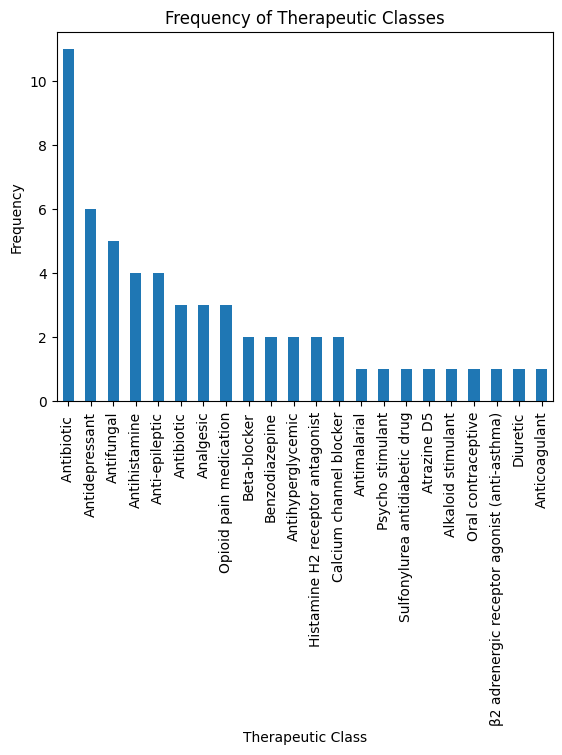

In [ ]:
# Making barplot based on the therapuetic class of all 58 APIs

#I import and load the dataset
Table1_df = pd.read_csv("TableS1.txt", sep = ",")
Table1_df

#selected the therapeutic class for the barchart
freq = Table1_df["Therapeutic Class"].value_counts()
freq.plot(kind='bar')
plt.title('Frequency of Therapeutic Classes')
plt.xlabel('Therapeutic Class')
plt.ylabel('Frequency')

**Exploratory 2**

Text(0.5, 1.0, 'Distribution of API Classes (Base, Acid, Neutral, Zwitterion)')

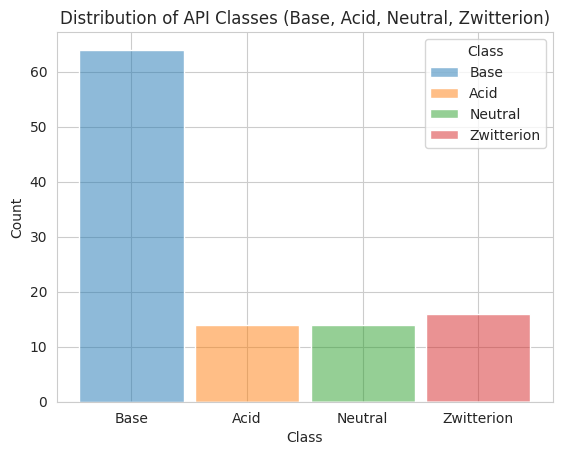

In [ ]:
#I import and load the dataset
Bar_df = pd.read_csv("TableS14.txt", sep = ",", header = 0)
Bar_df

#Selecting the first three column
Bar_df = Bar_df.iloc[:,0:3]

#Filling the Missing Class
Bar_df['Class'] = Bar_df['Class'].fillna(method='ffill')

sns.histplot(data = Bar_df, x = "Class", hue= "Class", shrink = 0.9)
plt.title('Distribution of API Classes (Base, Acid, Neutral, Zwitterion)')


**Exploratory 3**

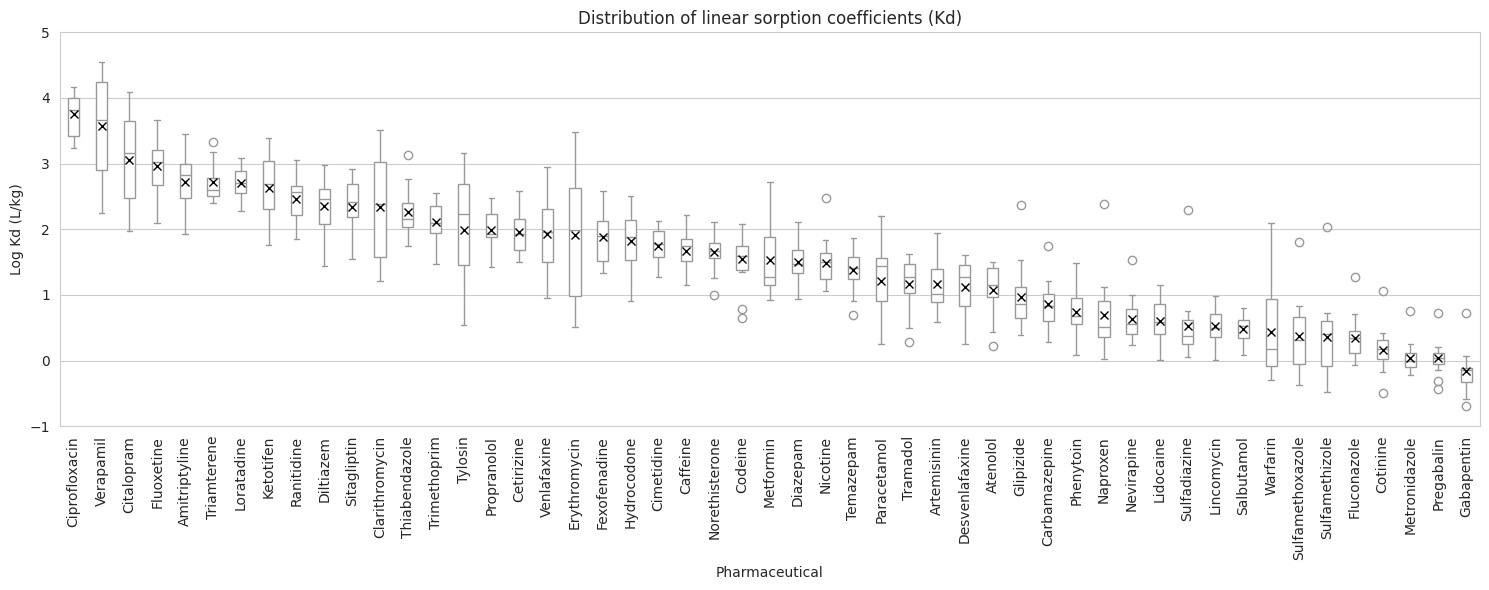

In [ ]:
#I import and load the datasets with API of 13 alone
API_df = pd.read_csv('TableS12.txt', sep=',')
Complete_APIs = API_df["Pharmaceutical"].value_counts()
Complete_APIs = Complete_APIs[Complete_APIs == 13].index
API_df = API_df[API_df["Pharmaceutical"].isin(Complete_APIs)]

#I
ordered_APIs = API_df.groupby("Pharmaceutical")["Log Kd"].mean().sort_values(ascending=False).index

# Created  the boxplot with mean
plt.figure(figsize=(15, 6))
sns.set_style("whitegrid")
sns.boxplot(
    x='Pharmaceutical',
    y='Log Kd',
    data=API_df,
    order=ordered_APIs,
    flierprops={'marker': 'o'},
    meanprops={'marker': 'x', 'markeredgecolor': 'black'},
    showmeans=True,
    width=0.4,
    color='white'
)

#designed plot
plt.title('Distribution of linear sorption coefficients (Kd)')
plt.xlabel('Pharmaceutical')
plt.ylabel('Log Kd (L/kg)')
plt.xticks(rotation=90)
plt.ylim(-1, 5)
plt.tight_layout()
plt.show()


**Modelling Exercise: Ridge Regression with MOL and SOL**



In [ ]:
#I imported and load dataset
API_df = pd.read_csv('TableS12.txt', sep=',', header=0)

#Then drop rows with missing values
API_df = API_df.dropna()

#Listed out the exact column names I need:
molecular_cols = ['UI','Charge 1+','Log Sw', 'DB','Charge 1+1-',  'Charge 1-']
solid_cols = ['soil_TOC','soil_pH ']

#Then i combine them into 1 df
selected_cols = molecular_cols + solid_cols
df_subset = API_df[selected_cols]
df_subset

# Call to_numpy with parentheses to actually execute the function
X = df_subset.to_numpy()
y = API_df['Log Kd'].to_numpy()

#I split into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 200, random_state = 1)


In [ ]:
#I made a pipeline to standardize and cross validate
pipe = make_pipeline(StandardScaler(), Ridge())
md1_cv = GridSearchCV(pipe, param_grid={"ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}, cv=10, scoring="neg_mean_absolute_error")
md1_cv.fit(X_train, y_train)


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             param_grid={'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             scoring='neg_mean_absolute_error')

In [ ]:
# look at the best parameters (alpha)
md1_cv.best_params_

{'ridge__alpha': 0.001}

In [ ]:
# make predictions using best model on both test and train set
prediction = md1_cv.predict(X_test)
predict = md1_cv.predict(X_train)


In [ ]:
#test accuracy
# Evaluate the model on training data
train_mse = mean_squared_error(y_train, predict)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, predict)

# Evaluate the model on test data
test_mse = mean_squared_error(y_test, prediction)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, prediction)

# Output results
print("Training - Mean Squared Error:", train_mse)
print("Training - Root Mean Squared Error:", train_rmse)
print("Training - R-squared:", train_r2)
print("Test - Mean Squared Error:", test_mse)
print("Test - Root Mean Squared Error:", test_rmse)
print("Test - R-squared:", test_r2)

Training - Mean Squared Error: 0.4507677340165057
Training - Root Mean Squared Error: 0.6713923845386583
Training - R-squared: 0.6406627364252238
Test - Mean Squared Error: 0.5888586688944705
Test - Root Mean Squared Error: 0.7673712718720127
Test - R-squared: 0.5374994885464217


**Ridge regression model with MOL and SOL compared to TableS11a**


Evaluation on TableS11-A.txt:
Mean Squared Error: 0.5884568119019276
Root Mean Squared Error: 0.7671093871814681
R-squared: 0.31487427069032226


Text(0.5, 1.0, 'Ridge regression compared with TableS11A)')

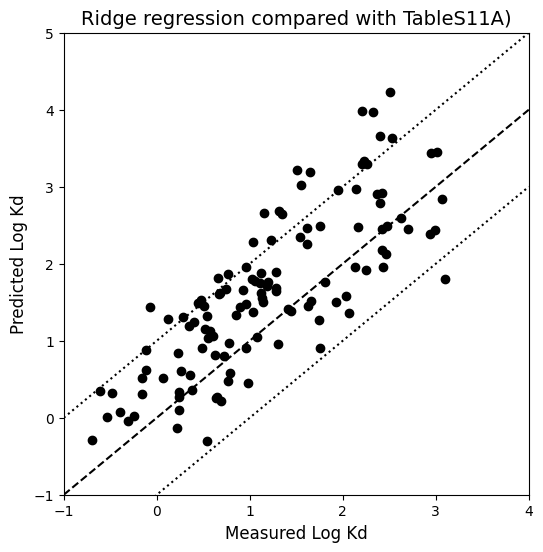

In [ ]:
# Testing Ridge regression on TableS11_A.txt
#Load the new dataset (TableS11-A.txt)
new_df = pd.read_csv('TableS11-A.txt', sep=',', header=0)
# Drop rows with missing values (if any)
new_df = new_df.dropna()


#Selected just the 'log kd' column as the target(y)
X_new = new_df[selected_cols].to_numpy()
y_new_RGA = new_df['Log Kd'].to_numpy()

#Predict Log Kd using the trained Ridge regression model and scaling from the training
y_pred_RGA = md1_cv.predict(X_new)

#Evaluate the model on the new test data
new_mse = mean_squared_error(y_new_RGA, y_pred_RGA)
new_rmse = np.sqrt(new_mse)
new_r2 = r2_score(y_new_RGA, y_pred_RGA)

# Output results for the new test data
print("\nEvaluation on TableS11-A.txt:")
print("Mean Squared Error:", new_mse)
print("Root Mean Squared Error:", new_rmse)
print("R-squared:", new_r2)


#Created a scatter plot of predicted vs measured Log Kd
plt.figure(figsize=(6, 6))
plt.scatter(y_new_RGA, y_pred_RGA, c='black')

plt.plot([-1, 4], [-1, 4], 'k--')                            # Diagonal line (perfect prediction)
plt.plot([-1, 4], [ 0,  5], 'k:')                           # Upper bound of ±1 unit
plt.plot([-1, 4], [-2,  3], 'k:')                           # Lower bound of ±1 unit
plt.xlim(-1, 4)
plt.ylim(-1, 5)
plt.xlabel('Measured Log Kd', fontsize=12)
plt.ylabel('Predicted Log Kd', fontsize=12)
plt.title('Ridge regression compared with TableS11A)', fontsize=14)

**Ridge regression with only MOL**

In [ ]:
#I imported and load the dataset
API_df = pd.read_csv('TableS12.txt', sep=',', header=0)

#Then drop rows with missing values
API_df = API_df.dropna()

#Listed out the exact column names you want:
molecular_cols = ['UI','Charge 1+','Log Sw', 'DB','Charge 1+1-',  'Charge 1-']
molecular_cols

#I added the mol column into a new df
df_subset = API_df[molecular_cols]

# Call to_numpy with parentheses to actually execute the function
X = df_subset.to_numpy()      # shape (n_samples, 27)
y = API_df['Log Kd'].to_numpy()   # leave your target column alone


#I split into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 200, random_state = 1)

In [ ]:
#I made a pipeline to standardize and cross validate
pipe = make_pipeline(StandardScaler(), Ridge())
md1_cv = GridSearchCV(pipe, param_grid={"ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}, cv=10, scoring="neg_mean_absolute_error")
md1_cv.fit(X_train, y_train)


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             param_grid={'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             scoring='neg_mean_absolute_error')

In [ ]:
# look at the best parameters (alpha)
md1_cv.best_params_

{'ridge__alpha': 0.001}

In [ ]:
# make predictions using best model on both test and train set
prediction = md1_cv.predict(X_test)
predict = md1_cv.predict(X_train)

In [ ]:
#Testing the accuracy
#Evaluating the model on both data because both the test and train data was done in the article
train_mse = mean_squared_error(y_train, predict)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, predict)

# Evaluate the model on test data
test_mse = mean_squared_error(y_test, prediction)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, prediction)

# Output results
print("Training - Mean Squared Error:", train_mse)
print("Training - Root Mean Squared Error:", train_rmse)
print("Training - R-squared:", train_r2)
print("Test - Mean Squared Error:", test_mse)
print("Test - Root Mean Squared Error:", test_rmse)
print("Test - R-squared:", test_r2)

Training - Mean Squared Error: 0.49667454690627455
Training - Root Mean Squared Error: 0.7047514078781784
Training - R-squared: 0.6040673297924928
Test - Mean Squared Error: 0.6580367338731477
Test - Root Mean Squared Error: 0.8111946337798024
Test - R-squared: 0.48316575428370867


**Ridge regression model with only MOL compared to  TableS11b**


Evaluation on TableS11-B.txt:
Mean Squared Error: 0.842156049871836
Root Mean Squared Error: 0.917690606834262
R-squared: 0.5265670465395416


Text(0.5, 1.0, 'Ridge regression compared with TableS11B)')

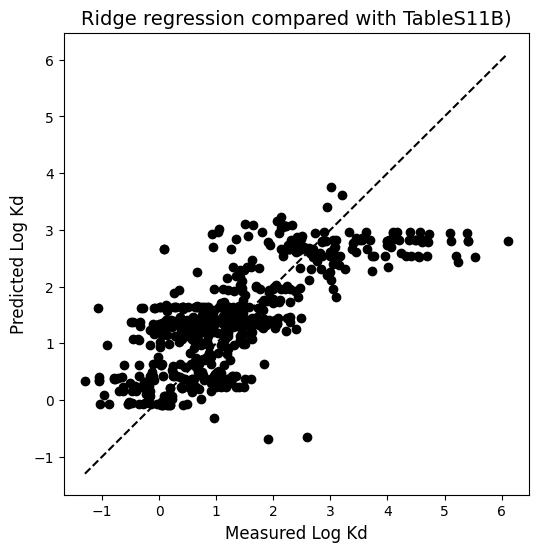

In [ ]:
# Testing Ridge regression on TableS11_B.txt
# Load the new dataset (TableS11-B.txt)
new_df = pd.read_csv('TableS11-B.txt', sep=',', header=0)
# Drop rows with missing values (if any)
new_df = new_df.dropna()


#Selected just the 'log kd' column as your target vector y
X_new = new_df[molecular_cols].to_numpy()
y_new_RGB = new_df['Log Kd'].to_numpy()

#Predict Log Kd using the trained Ridge regression model and the same scaling
y_pred_RGB = md1_cv.predict(X_new)


#Evaluate the model on the new test data
new_mse = mean_squared_error(y_new_RGB, y_pred_RGB)
new_rmse = np.sqrt(new_mse)
new_r2 = r2_score(y_new_RGB, y_pred_RGB)

# Output results for the new test data
print("\nEvaluation on TableS11-B.txt:")
print("Mean Squared Error:", new_mse)
print("Root Mean Squared Error:", new_rmse)
print("R-squared:", new_r2)


# Step 5: Create a scatter plot of predicted vs measured Log Kd
plt.figure(figsize=(6, 6))
plt.scatter(y_new_RGB, y_pred_RGB, c='black')
#plt.plot([-2, 7], [-2, 7], 'k--')  # Diagonal line (perfect prediction)
#plt.plot([-2, 7], [0, 9], 'k:',)  # Upper bound of ±1 unit
#plt.plot([-2, 7], [-4, 5], 'k:')        # Lower bound of ±1 unit
plt.plot([y_new_RGB.min(), y_new_RGB.max()],
         [y_new_RGB.min(), y_new_RGB.max()], 'k--')
plt.xlabel('Measured Log Kd', fontsize=12)
plt.ylabel('Predicted Log Kd', fontsize=12)
plt.title('Ridge regression compared with TableS11B)', fontsize=14)

**Random Forest  with MOL and SOL**

In [ ]:
# imported and load dataset
API_df = pd.read_csv('TableS12.txt', sep=',', header=0)
# drop rows with missing values
API_df = API_df.dropna()

#List out the exact column names you want:
molecular_cols = [
    'MV','UI','Charge 1+','Log Sw','Log Dow','RB','Log Kow',
    'Charge 1-','TPSA','pKa','Charge 0','HBA','HF','M LogP',
    'DB','NR','Charge 1+1-','NSA','Nai'
]
solid_cols = ['soil_TOC','soil_pH ','soil_K','soil_Na','soil_silt','soil_Mg','soil_CEC','soil_Clay']

#Combine them and added into a new df
selected_cols = molecular_cols + solid_cols
df_subset = API_df[selected_cols]


# Call to_numpy with parentheses to actually execute the function
X = df_subset.to_numpy()
y = API_df['Log Kd'].to_numpy()


# Set random seed for reproducibility
seed = 0

# Train - Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = seed)
# standardize the data
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# CREATE random forest regressor object
random_forest_regressor = ensemble.RandomForestRegressor()


param_grid = {
    "max_features": [2, 3, 4],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 6, 20]}
rf_CV = GridSearchCV(random_forest_regressor, param_grid = param_grid, cv = 10 )

# FIT the training data to the regressor
rf_CV.fit(X_train, y_train)


# CALCULATE accuracy of the train and test sets
train_predictions = rf_CV.predict(X_train)
test_predictions = rf_CV.predict(X_test)

r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("Train set R-squared (R²) is: {} and test set R-squared (R²): {}".format(round(r2_train, 4),
                                                                                          round(r2_test, 4)))
mean_abs_error_train = np.mean(np.abs(y_train - train_predictions))
mean_abs_error_test = np.mean(np.abs(y_test - test_predictions))
print("Train set mean absolute error is: {} and test set mean absolute error is: {}".format(round(mean_abs_error_train, 4),
                                                                                            round(mean_abs_error_test, 4)))
mean_squared_error_train = np.mean((y_train - train_predictions)**2)
mean_squared_error_test = np.mean((y_test - test_predictions)**2)
print("Train set mean squared error is: {} and test set mean squared error is: {}".format(round(mean_squared_error_train, 4),
                                                                                          round(mean_squared_error_test, 4)))

root_mean_squared_error_train = np.sqrt(mean_squared_error_train)
root_mean_squared_error_test = np.sqrt(mean_squared_error_test)
print("Train set root mean squared error is: {} and test set root mean squared error is: {}".format(round(root_mean_squared_error_train, 4),
                                                                                                    round(root_mean_squared_error_test, 4)))

Train set R-squared (R²) is: 0.9887 and test set R-squared (R²): 0.9046
Train set mean absolute error is: 0.0869 and test set mean absolute error is: 0.2553
Train set mean squared error is: 0.014 and test set mean squared error is: 0.1263
Train set root mean squared error is: 0.1184 and test set root mean squared error is: 0.3554


**Random Forest model with MOL and SOL compared to 11a**


Evaluation on TableS11-A.txt:
Mean Squared Error: 0.4384501337867767
Root Mean Squared Error: 0.6621556718678597
R-squared: 0.48952334036936107


Text(0.5, 1.0, 'RF regression(A)')

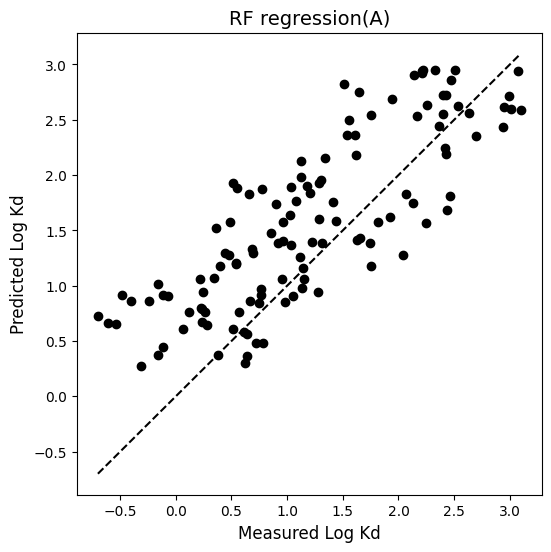

In [ ]:
# Testing Random Forest on TableS11_A.txt
#Load the new dataset (TableS11-A.txt)
new_df = pd.read_csv('TableS11-A.txt', sep=',', header=0)
# Drop rows with missing values (if any)
new_df = new_df.dropna()

#I selected just the 'log kd' column as your target vector y
X_new = new_df[selected_cols].to_numpy()
y_new_RFA = new_df['Log Kd'].to_numpy()

#Used the scaling from the training data
X_new_scaled = scaler.transform(X_new)


#To predict Log Kd using the trained Random Forest regression model
y_pred_RFA = rf_CV.predict(X_new_scaled)

#Evaluate the model on the new test data
new_mse = mean_squared_error(y_new_RFA, y_pred_RFA)
new_rmse = np.sqrt(new_mse)
new_r2 = r2_score(y_new_RFA, y_pred_RFA)

# Output results for the new test data
print("\nEvaluation on TableS11-A.txt:")
print("Mean Squared Error:", new_mse)
print("Root Mean Squared Error:", new_rmse)
print("R-squared:", new_r2)


# Step 5: Create a scatter plot of predicted vs measured Log Kd
plt.figure(figsize=(6, 6))
plt.scatter(y_new_RFA, y_pred_RFA, c='black')
plt.plot([y_new_RFA.min(), y_new_RFA.max()],
         [y_new_RFA.min(), y_new_RFA.max()], 'k--')

#plt.plot([-2, 7], [-2, 7], 'k--')  # Diagonal line (perfect prediction)
#plt.plot([-2, 7], [0, 9], 'k:',)  # Upper bound of ±1 unit
#plt.plot([-2, 7], [-4, 5], 'k:')        # Lower bound of ±1 unit
plt.xlabel('Measured Log Kd', fontsize=12)
plt.ylabel('Predicted Log Kd', fontsize=12)
plt.title('RF regression(A)', fontsize=14)

**Random Forest with only MOL**

In [ ]:
# imported and load dataset
API_df = pd.read_csv('TableS12.txt', sep=',', header=0)
# drop rows with missing values
API_df = API_df.dropna()

#List out the exact column names you want:
molecular_cols = [
    'MV','UI','Charge 1+','Log Sw','Log Dow','RB','Log Kow',
    'Charge 1-','TPSA','pKa','Charge 0','HBA','HF','M LogP',
    'DB','NR','Charge 1+1-','NSA','Nai'
]

# Add the mol into a new df
molecular_cols
df_subset = API_df[molecular_cols]


# Call to_numpy with parentheses to actually execute the function
X = df_subset.to_numpy()
y = API_df['Log Kd'].to_numpy()


# Set random seed for reproducibility
seed = 0

# Train - Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = seed)
# standardize the data
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# CREATE random forest regressor object
random_forest_regressor = ensemble.RandomForestRegressor()


param_grid = {
    "max_features": [2, 3, 4],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 6, 20]}
rf_CV = GridSearchCV(random_forest_regressor, param_grid = param_grid, cv = 10 )

# FIT the training data to the regressor
rf_CV.fit(X_train, y_train)


# CALCULATE accuracy of the train and test sets
train_predictions = rf_CV.predict(X_train)
test_predictions = rf_CV.predict(X_test)

r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("Train set R-squared (R²) is: {} and test set R-squared (R²): {}".format(round(r2_train, 4),
                                                                                          round(r2_test, 4)))
mean_abs_error_train = np.mean(np.abs(y_train - train_predictions))
mean_abs_error_test = np.mean(np.abs(y_test - test_predictions))
print("Train set mean absolute error is: {} and test set mean absolute error is: {}".format(round(mean_abs_error_train, 4),
                                                                                            round(mean_abs_error_test, 4)))
mean_squared_error_train = np.mean((y_train - train_predictions)**2)
mean_squared_error_test = np.mean((y_test - test_predictions)**2)
print("Train set mean squared error is: {} and test set mean squared error is: {}".format(round(mean_squared_error_train, 4),
                                                                                          round(mean_squared_error_test, 4)))

root_mean_squared_error_train = np.sqrt(mean_squared_error_train)
root_mean_squared_error_test = np.sqrt(mean_squared_error_test)
print("Train set root mean squared error is: {} and test set root mean squared error is: {}".format(round(root_mean_squared_error_train, 4),
                                                                                                    round(root_mean_squared_error_test, 4)))

Train set R-squared (R²) is: 0.9703 and test set R-squared (R²): 0.8426
Train set mean absolute error is: 0.1511 and test set mean absolute error is: 0.3394
Train set mean squared error is: 0.0368 and test set mean squared error is: 0.2084
Train set root mean squared error is: 0.1918 and test set root mean squared error is: 0.4565


**Random Forest model with only MOL compared to 11b**


Evaluation on TableS11-B.txt:
Mean Squared Error: 0.6425238090158537
Root Mean Squared Error: 0.8015758286125235
R-squared: 0.638793849884077


Text(0.5, 1.0, 'RF regression(B)')

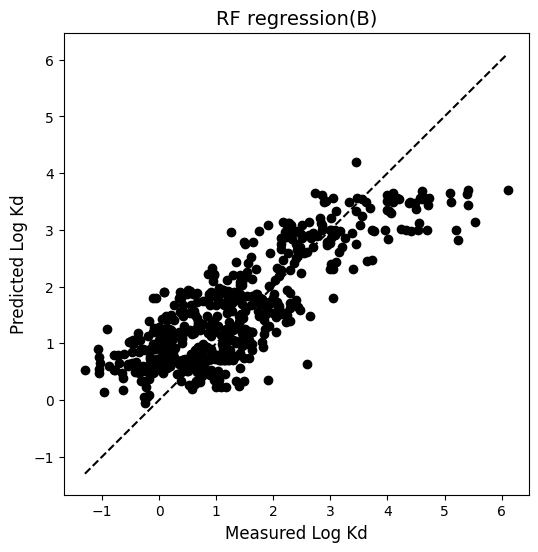

In [ ]:
# Testing Random Forest on TableS11_B.txt
#Load the new dataset (TableS11-B.txt)
new_df = pd.read_csv('TableS11-B.txt', sep=',', header=0)
# Drop rows with missing values (if any)
new_df = new_df.dropna()


#Selected just the 'log kd' column as your target vector y
X_new = new_df[molecular_cols].to_numpy()
y_new_RFB = new_df['Log Kd'].to_numpy()

#Use the scaling from the training data
X_new_scaled = scaler.transform(X_new)

#Predict Log Kd using the trained Random Forest regression model
y_pred_RFB = rf_CV.predict(X_new_scaled)

#Evaluate the model on the new test data
new_mse = mean_squared_error(y_new_RFB, y_pred_RFB)
new_rmse = np.sqrt(new_mse)
new_r2 = r2_score(y_new_RFB, y_pred_RFB)

# Output results for the new test data
print("\nEvaluation on TableS11-B.txt:")
print("Mean Squared Error:", new_mse)
print("Root Mean Squared Error:", new_rmse)
print("R-squared:", new_r2)


# Step 5: Create a scatter plot of predicted vs measured Log Kd
plt.figure(figsize=(6, 6))
plt.scatter(y_new_RFB, y_pred_RFB, c='black')
plt.plot([y_new_RFB.min(), y_new_RFB.max()],
         [y_new_RFB.min(), y_new_RFB.max()], 'k--')
#plt.plot([-2, 7], [-2, 7], 'k--')  # Diagonal line (perfect prediction)
#plt.plot([-2, 7], [0, 9], 'k:',)  # Upper bound of ±1 unit
#plt.plot([-2, 7], [-4, 5], 'k:')        # Lower bound of ±1 unit
plt.xlabel('Measured Log Kd', fontsize=12)
plt.ylabel('Predicted Log Kd', fontsize=12)
plt.title('RF regression(B)', fontsize=14)

**SVR model with MOL and SOL**

In [ ]:
# imported and load the dataset
API_df = pd.read_csv('TableS12.txt', sep=',', header=0)
# drop rows with missing values
API_df = API_df.dropna()

#Listed out the exact column names i need:
molecular_cols = ['UI','Charge 1+','Log Sw','Log Dow','Charge 1-','TPSA','pKa','HBA','M LogP',
    'DB','NR','Charge 1+1-','NSA','Nai']

solid_cols = ['soil_TOC','soil_pH ','soil_K','soil_Na','soil_silt']

#Combine them into a df
selected_cols = molecular_cols + solid_cols
df_subset = API_df[selected_cols]



# Call to_numpy with parentheses to actually execute the function
X = df_subset.to_numpy()
y = API_df['Log Kd'].to_numpy()


# split train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 200, random_state = 1)

In [ ]:
# made a pipeline
Mdl = make_pipeline(StandardScaler(),
                    SVR(C = 2, kernel = "rbf", gamma = 1/5))
# tuning the model
# define grid of parameters
param_grid = {"svr__C": [0.1, 1, 10, 100, 1000],
              "svr__gamma": [0.001, 0.01, 0.1, 1, 10]}

# create GridSearchCV object
Mdl_cv = GridSearchCV(Mdl,  # model object (in this case the pipeline)
                      param_grid,        # parameter grid
                      cv = 10,           # number of folds
                      scoring = "neg_mean_absolute_error")  # criterion used to select best model

# perform grid search (after the grid search, mdl_cv.predict(X) will predict using best model)
Mdl_cv.fit(X_train, y_train)

# inspect the best parameters
Mdl_cv.best_params_

{'svr__C': 100, 'svr__gamma': 0.01}

In [ ]:
#CALCULATE accuracy of the train and test sets
train_predictions = Mdl_cv.predict(X_train)
test_predictions = Mdl_cv.predict(X_test)

r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("Train set R-squared (R²) is: {} and test set R-squared (R²): {}".format(round(r2_train, 4),
                                                                                          round(r2_test, 4)))
mean_abs_error_train = np.mean(np.abs(y_train - train_predictions))
mean_abs_error_test = np.mean(np.abs(y_test - test_predictions))
print("Train set mean absolute error is: {} and test set mean absolute error is: {}".format(round(mean_abs_error_train, 4),
                                                                                            round(mean_abs_error_test, 4)))
mean_squared_error_train = np.mean((y_train - train_predictions)**2)
mean_squared_error_test = np.mean((y_test - test_predictions)**2)
print("Train set mean squared error is: {} and test set mean squared error is: {}".format(round(mean_squared_error_train, 4),
                                                                                          round(mean_squared_error_test, 4)))

root_mean_squared_error_train = np.sqrt(mean_squared_error_train)
root_mean_squared_error_test = np.sqrt(mean_squared_error_test)
print("Train set root mean squared error is: {} and test set root mean squared error is: {}".format(round(root_mean_squared_error_train, 4),
                                                                                                    round(root_mean_squared_error_test, 4)))


Train set R-squared (R²) is: 0.9666 and test set R-squared (R²): 0.9172
Train set mean absolute error is: 0.1301 and test set mean absolute error is: 0.2368
Train set mean squared error is: 0.0419 and test set mean squared error is: 0.1054
Train set root mean squared error is: 0.2048 and test set root mean squared error is: 0.3247


**SVM model with MOL and SOL compared to 11a**


Evaluation on TableS11-A.txt:
Mean Squared Error: 2.9922602615748275
Root Mean Squared Error: 1.7298150946198925
R-squared: -2.483814704038955


Text(0.5, 1.0, 'SVM regression compared to Table- S11A')

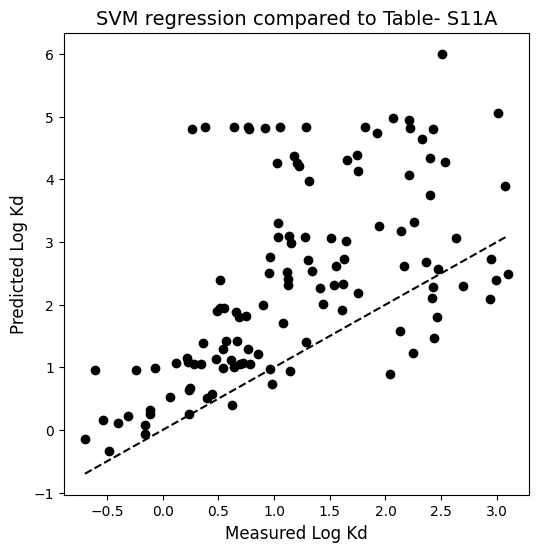

In [ ]:
# Testing SVR regression on TableS11_A.txt
#Load the new dataset (TableS11-A.txt)
new_df = pd.read_csv('TableS11-A.txt', sep=',', header=0)
# Drop rows with missing values (if any)
new_df = new_df.dropna()


#Selected just the 'log kd' column as target (y)
X_new = new_df[selected_cols].to_numpy()
y_new_SVMa = new_df['Log Kd'].to_numpy()


#Predict Log Kd using the trained Ridge regression model and the same scaling
y_pred_SVMa = Mdl_cv.predict(X_new)

#Evaluate the model on the new test data
new_mse = mean_squared_error(y_new_SVMa, y_pred_SVMa)
new_rmse = np.sqrt(new_mse)
new_r2 = r2_score(y_new_SVMa, y_pred_SVMa)

# Output results for the new test data
print("\nEvaluation on TableS11-A.txt:")
print("Mean Squared Error:", new_mse)
print("Root Mean Squared Error:", new_rmse)
print("R-squared:", new_r2)


# Step 5: Create a scatter plot of predicted vs measured Log Kd
plt.figure(figsize=(6, 6))
plt.scatter(y_new_SVMa, y_pred_SVMa, c='black')
plt.plot([y_new_SVMa.min(), y_new_SVMa.max()],
         [y_new_SVMa.min(), y_new_SVMa.max()], 'k--')

#plt.plot([-2, 7], [-2, 7], 'k--')  # Diagonal line (perfect prediction)
#plt.plot([-2, 7], [0, 9], 'k:',)  # Upper bound of ±1 unit
#plt.plot([-2, 7], [-4, 5], 'k:')        # Lower bound of ±1 unit
plt.xlabel('Measured Log Kd', fontsize=12)
plt.ylabel('Predicted Log Kd', fontsize=12)
plt.title('SVM regression compared to Table- S11A', fontsize=14)

**SVM model with only MOL**

In [ ]:
# imported the dataset
API_df = pd.read_csv('TableS12.txt', sep=',', header=0)
# drop rows with missing values
API_df = API_df.dropna()

#List out the exact column names I want:
molecular_cols = ['UI','Charge 1+','Log Sw','Log Dow','Charge 1-','TPSA','pKa','HBA','M LogP',
    'DB','NR','Charge 1+1-','NSA','Nai']

#I combined them into 1 df
molecular_cols
df_subset = API_df[molecular_cols]

# Call to_numpy with parentheses to actually execute the function
X = df_subset.to_numpy()
y = API_df['Log Kd'].to_numpy()

# Set random seed for reproducibility
seed = 0

# Train - Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = seed)


In [ ]:
# made a pipeline
Mdl = make_pipeline(StandardScaler(),
                    SVR(C = 2, kernel = "rbf", gamma = 1/5))
# tuning the model
# define grid of parameters
param_grid = {"svr__C": [0.1, 1, 10, 100],
              "svr__gamma": [0.001, 0.01, 0.1, 1, 10]}

# create GridSearchCV object
Mdl_cv = GridSearchCV(Mdl,  # model object (in this case the pipeline)
                      param_grid,        # parameter grid
                      cv = 10,           # number of folds
                      scoring = "neg_mean_absolute_error")  # criterion used to select best model

# perform grid search (after the grid search, mdl_cv.predict(X) will predict using best model)
Mdl_cv.fit(X_train, y_train)

# inspect the best parameters
Mdl_cv.best_params_

{'svr__C': 10, 'svr__gamma': 0.1}

In [ ]:
#CALCULATE accuracy of the train and test sets
train_predictions = Mdl_cv.predict(X_train)
test_predictions = Mdl_cv.predict(X_test)

r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("Train set R-squared (R²) is: {} and test set R-squared (R²): {}".format(round(r2_train, 4),
                                                                                          round(r2_test, 4)))
mean_abs_error_train = np.mean(np.abs(y_train - train_predictions))
mean_abs_error_test = np.mean(np.abs(y_test - test_predictions))
print("Train set mean absolute error is: {} and test set mean absolute error is: {}".format(round(mean_abs_error_train, 4),
                                                                                            round(mean_abs_error_test, 4)))
mean_squared_error_train = np.mean((y_train - train_predictions)**2)
mean_squared_error_test = np.mean((y_test - test_predictions)**2)
print("Train set mean squared error is: {} and test set mean squared error is: {}".format(round(mean_squared_error_train, 4),
                                                                                          round(mean_squared_error_test, 4)))

root_mean_squared_error_train = np.sqrt(mean_squared_error_train)
root_mean_squared_error_test = np.sqrt(mean_squared_error_test)
print("Train set root mean squared error is: {} and test set root mean squared error is: {}".format(round(root_mean_squared_error_train, 4),
                                                                                                    round(root_mean_squared_error_test, 4)))

Train set R-squared (R²) is: 0.9312 and test set R-squared (R²): 0.8213
Train set mean absolute error is: 0.2217 and test set mean absolute error is: 0.3447
Train set mean squared error is: 0.0852 and test set mean squared error is: 0.2366
Train set root mean squared error is: 0.2918 and test set root mean squared error is: 0.4864


**SVM model with only MOL compared to 11b**


Evaluation on TableS11-B.txt:
Mean Squared Error: 1.053297535206335
Root Mean Squared Error: 1.0263028477044849
R-squared: 0.40787011737166035


Text(0.5, 1.0, 'SVM regression(B)')

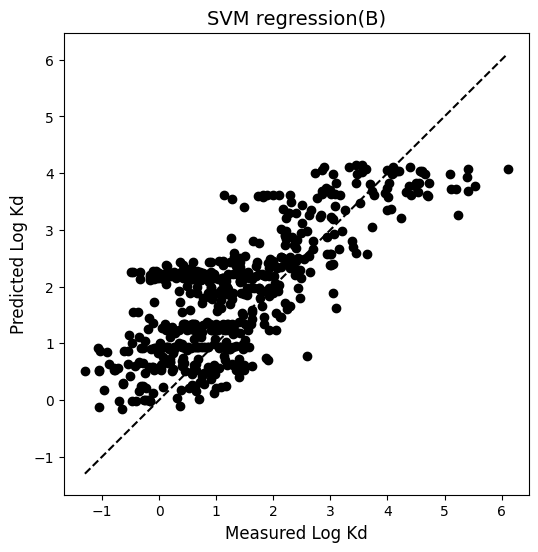

In [ ]:
# Testing SVM on TableS11_B.txt
#Load the new dataset (TableS11-B.txt)
new_df = pd.read_csv('TableS11-B.txt', sep=',', header=0)
# Drop rows with missing values (if any)
new_df = new_df.dropna()


#Selected just the 'log kd' column as your target vector y
X_new = new_df[molecular_cols].to_numpy()
y_new_SVMb = new_df['Log Kd'].to_numpy()


#Predict Log Kd using the trained Ridge regression model and the same scaling
y_pred_SVMb = Mdl_cv.predict(X_new)

#Evaluate the model on the new test data
new_mse = mean_squared_error(y_new_SVMb, y_pred_SVMb)
new_rmse = np.sqrt(new_mse)
new_r2 = r2_score(y_new_SVMb, y_pred_SVMb)

# Output results for the new test data
print("\nEvaluation on TableS11-B.txt:")
print("Mean Squared Error:", new_mse)
print("Root Mean Squared Error:", new_rmse)
print("R-squared:", new_r2)


#Create a scatter plot of predicted vs measured Log Kd
plt.figure(figsize=(6, 6))
plt.scatter(y_new_SVMb, y_pred_SVMb, c='black')
plt.plot([y_new_SVMb.min(), y_new_SVMb.max()],
         [y_new_SVMb.min(), y_new_SVMb.max()], 'k--')
#plt.plot([-1, 4], [-1, 4], 'k--')  # Diagonal line (perfect prediction)
#plt.plot([-2, 7], [0, 9], 'k:',)  # Upper bound of ±1 unit
#plt.plot([-2, 7], [-4, 5], 'k:')        # Lower bound of ±1 unit
plt.xlabel('Measured Log Kd', fontsize=12)
plt.ylabel('Predicted Log Kd', fontsize=12)
plt.title('SVM regression(B)', fontsize=14)

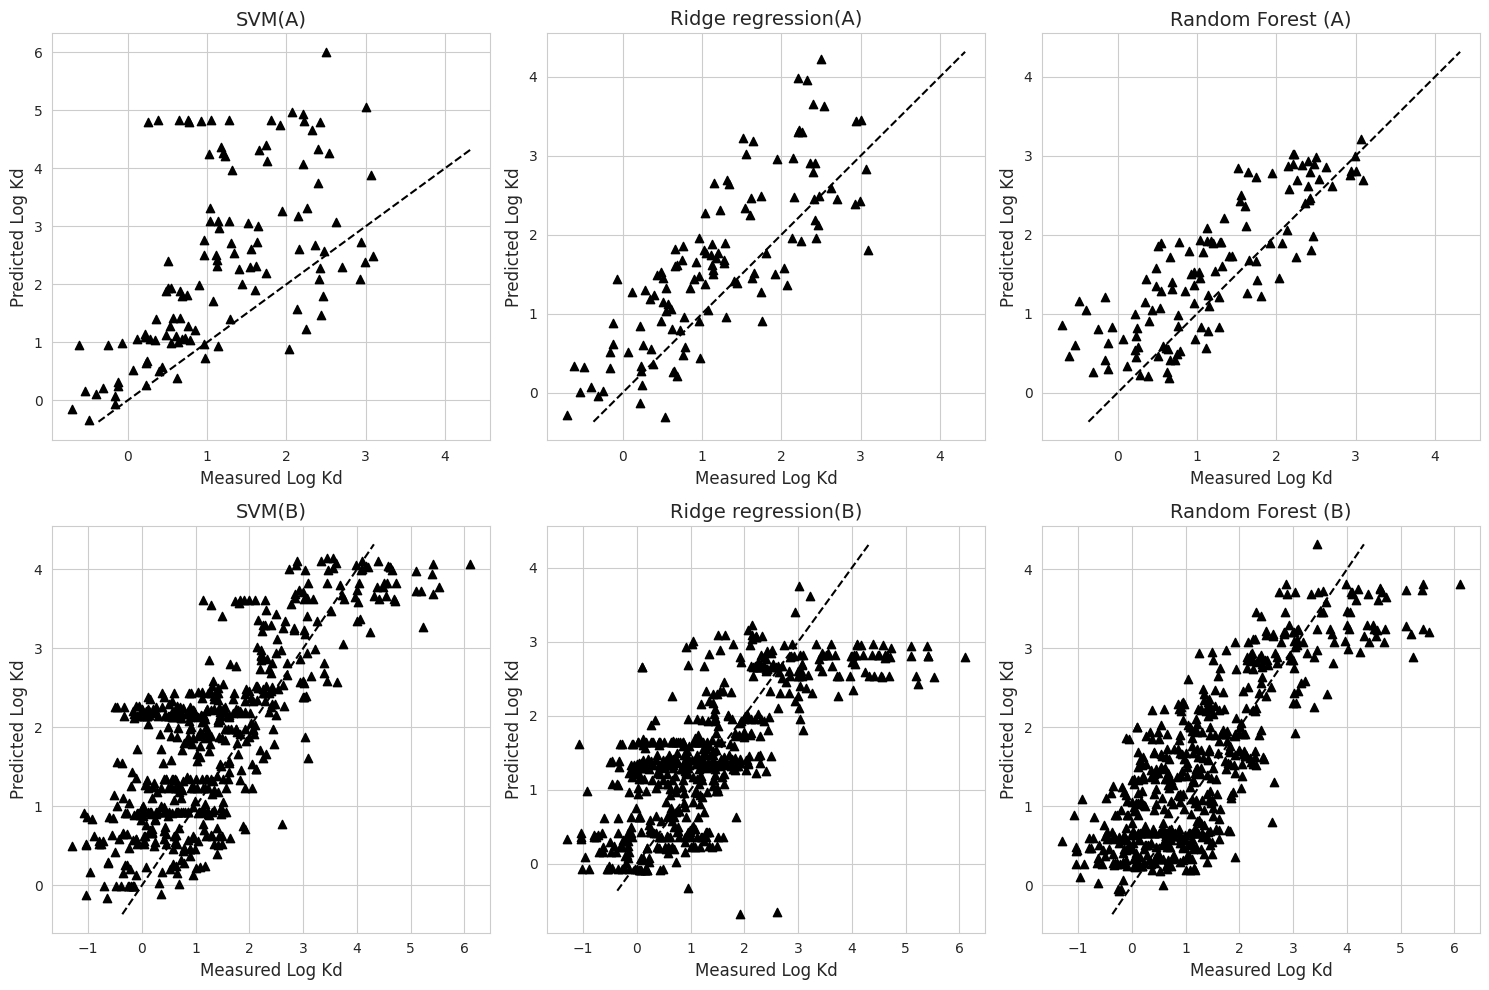

In [ ]:
# Create a 2x3 subplot grid (since you used 2 rows and 3 columns)
plt.figure(figsize=(15, 10))

# Step 5: Create a scatter plot of predicted vs measured Log Kd
plt.subplot(2, 3, 1)
plt.scatter(y_new_SVMa, y_pred_SVMa, c='black', marker='^')
plt.plot([y_new_SVMa.min(), y_new_SVMa.max()], [y_new_SVMa.min(), y_new_SVMa.max()], 'k--')
plt.xlabel('Measured Log Kd', fontsize=12)
plt.ylabel('Predicted Log Kd', fontsize=12)
plt.title('SVM(A)', fontsize=14)

# Step 5: Create a scatter plot of predicted vs measured Log Kd
plt.subplot(2, 3, 4)

plt.scatter(y_new_SVMb, y_pred_SVMb, c='black', marker='^')
plt.plot([y_new_SVMb.min(), y_new_SVMb.max()], [y_new_SVMb.min(), y_new_SVMb.max()], 'k--')
plt.xlabel('Measured Log Kd', fontsize=12)
plt.ylabel('Predicted Log Kd', fontsize=12)
plt.title('SVM(B)', fontsize=14)

# Step 5: Create a scatter plot of predicted vs measured Log Kd
plt.subplot(2, 3, 2)
plt.scatter(y_new_RGA, y_pred_RGA, c='black', marker='^')
plt.plot([y_new_RGA.min(), y_new_RGA.max()], [y_new_RGA.min(), y_new_RGA.max()], 'k--')
plt.xlabel('Measured Log Kd', fontsize=12)
plt.ylabel('Predicted Log Kd', fontsize=12)
plt.title('Ridge regression(A)', fontsize=14)

# Step 5: Create a scatter plot of predicted vs measured Log Kd
plt.subplot(2, 3, 5)
plt.scatter(y_new_RGB, y_pred_RGB, c='black', marker='^')
plt.plot([y_new_RGB.min(), y_new_RGB.max()], [y_new_RGB.min(), y_new_RGB.max()], 'k--')
plt.xlabel('Measured Log Kd', fontsize=12)
plt.ylabel('Predicted Log Kd', fontsize=12)
plt.title('Ridge regression(B)', fontsize=14)

# Step 5: Create a scatter plot of predicted vs measured Log Kd
plt.subplot(2, 3, 3)
plt.scatter(y_new_RFA, y_pred_RFA, c='black', marker='^')
plt.plot([y_new_RFA.min(), y_new_RFA.max()], [y_new_RFA.min(), y_new_RFA.max()], 'k--')
plt.xlabel('Measured Log Kd', fontsize=12)
plt.ylabel('Predicted Log Kd', fontsize=12)
plt.title('Random Forest (A)', fontsize=14)

# Step 5: Create a scatter plot of predicted vs measured Log Kd
plt.subplot(2, 3, 6)
plt.scatter(y_new_RFB, y_pred_RFB, c='black', marker='^')
plt.plot([y_new_RFB.min(), y_new_RFB.max()], [y_new_RFB.min(), y_new_RFB.max()], 'k--')
plt.xlabel('Measured Log Kd', fontsize=12)
plt.ylabel('Predicted Log Kd', fontsize=12)
plt.title('Random Forest (B)', fontsize=14)

plt.tight_layout()

SMILES

In [ ]:
pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 27.1 MB/s eta 0:00:00


In [ ]:
tableS12 = pd.read_csv("TableS12.txt", sep=',', header = 0)
tableS1 = pd.read_csv("TableS1.txt", sep=',', header = 0)
APIs = tableS12["Pharmaceutical"].to_numpy()
APIs
compound = tableS1["Compound"].to_numpy()
cas = tableS1["CAS"].to_numpy()
casnumber = []
for API in APIs:
    x = cas[compound == API]
    # print(x[0])
    casnumber.append(x[0])
casnumber
tableS12["CAS"] = casnumber

import requests
from rdkit import Chem
from rdkit.Chem import Descriptors

def get_smiles_from_cas(cas_number):
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{cas_number}/property/CanonicalSMILES/JSON"
    response = requests.get(url)
    if response.ok:
        data = response.json()
        return data['PropertyTable']['Properties'][0]['CanonicalSMILES']
    else:
        print(f"Failed to find SMILES for CAS: {cas_number}")
        return None



In [ ]:
MW = []
TPSA = []
LogP = []
HBA = []
i = 0
for cas in casnumber:#[:20]:
    smiles = get_smiles_from_cas(cas)
    mol = Chem.MolFromSmiles(smiles)
    mw = Descriptors.MolWt(mol)
    MW.append(mw)
    tpsa = Descriptors.TPSA(mol)
    TPSA.append(tpsa)
    logp = Descriptors.MolLogP(mol)
    LogP.append(logp)
    hba = Descriptors.NumHAcceptors(mol)
    HBA.append(hba)
    print(i)
    i = i+1
tableS12["MolWeight"] = MW
tableS12["TPSA"] = TPSA
tableS12["LogP"] = LogP
tableS12["HBA"] = HBA
tableS12





**SMILES with Ridge Regression**

In [ ]:
tableS12["TPSA"]

In [ ]:
# imported and load the dataset
NEWT12_df = tableS12
# drop rows with missing values
NEWT12_df = NEWT12_df.dropna()

#List out the exact column names you want:
molecular_cols = ['UI','Charge 1+','Log Sw', 'DB','Charge 1+1-', 'Charge 1-', 'soil_TOC','soil_pH ']


# 2) Combine them and slice your DataFrame:
Selected_cols = molecular_cols + ["MolWeight","TPSA","LogP","HBA"]
df_subset = NEWT12_df[Selected_cols]


# Call to_numpy with parentheses to actually execute the function
X = df_subset.to_numpy()
y = NEWT12_df['Log Kd'].to_numpy()


# split train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 200, random_state = 1)

# standardize the data
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)



In [ ]:
# define grid of parameters as a dictionary (obligatory for GridSearchCV)
param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

# create GridSearchCV object
md1_cv = GridSearchCV(Ridge(),           # model object (in this case a ridge regressor)
                      param_grid,        # parameter grid (range of values for alpha here)
                      cv = 10,           # number of folds
                      scoring = "neg_mean_absolute_error")  # criterion used to select best model

# perform grid search (after the grid search, mdl_cv.predict(X) will predict using best model)
md1_cv.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             scoring='neg_mean_absolute_error')

In [ ]:
# look at the best parameters (here just one value for alpha)
md1_cv.best_params_
# make predictions using best model on test set
prediction = md1_cv.predict(X_test)
predict = md1_cv.predict(X_train)

In [ ]:
#test accuracy
# Evaluate the model on training data
train_mse = mean_squared_error(y_train, predict)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, predict)

# Evaluate the model on test data
test_mse = mean_squared_error(y_test, prediction)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, prediction)

# Output results
print("Training - Mean Squared Error:", train_mse)
print("Training - Root Mean Squared Error:", train_rmse)
print("Training - R-squared:", train_r2)
print("Test - Mean Squared Error:", test_mse)
print("Test - Root Mean Squared Error:", test_rmse)
print("Test - R-squared:", test_r2)

Training - Mean Squared Error: 0.4201579747371905
Training - Root Mean Squared Error: 0.6481959385380246
Training - R-squared: 0.6650638332830325
Test - Mean Squared Error: 0.5565247685589351
Test - Root Mean Squared Error: 0.7460058770270748
Test - R-squared: 0.5628951330914018


**SMILES and RANDOM FOREST**

In [ ]:
#Imported and load the dataset
NEWT12_df = tableS12
# drop rows with missing values
NEWT12_df = NEWT12_df.dropna()

#List out the exact column names you want:
molecular_cols = [
    'MV','UI','Charge 1+','Log Sw','Log Dow','RB','Log Kow',
    'Charge 1-','TPSA','pKa','Charge 0','HBA','HF','M LogP',
    'DB','NR','Charge 1+1-','NSA','Nai','soil_TOC','soil_pH ','soil_K','soil_Na','soil_silt','soil_Mg','soil_CEC','soil_Clay']


#Combine them and slice your DataFrame:
Selected_cols = molecular_cols + ["MolWeight","TPSA","LogP","HBA"]
df_subset = NEWT12_df[Selected_cols]


# Call to_numpy with parentheses to actually execute the function
X = df_subset.to_numpy()
y = NEWT12_df['Log Kd'].to_numpy()


# Set random seed for reproducibility
seed = 0

# Train - Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = seed)
# standardize the data
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# CREATE random forest regressor object
random_forest_regressor = ensemble.RandomForestRegressor()


param_grid = {
    "max_features": [2, 3, 4],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 6, 20]}
GridSearchCV(random_forest_regressor, param_grid = param_grid, cv = 10 )
random_forest_regressor.fit(X_train, y_train)

# FIT the training data to the classifier
random_forest_regressor = random_forest_regressor.fit(X_train, y_train)

# CALCULATE accuracy of the train and test sets
train_predictions = random_forest_regressor.predict(X_train)
test_predictions = random_forest_regressor.predict(X_test)
mean_abs_error_train = np.mean(np.abs(y_train - train_predictions))
mean_abs_error_test = np.mean(np.abs(y_test - test_predictions))
print("Train set mean absolute error is: {} and test set mean absolute error is: {}".format(round(mean_abs_error_train, 4),
                                                                                            round(mean_abs_error_test, 4)))
mean_squared_error_train = np.mean((y_train - train_predictions)**2)
mean_squared_error_test = np.mean((y_test - test_predictions)**2)
print("Train set mean squared error is: {} and test set mean squared error is: {}".format(round(mean_squared_error_train, 4),
                                                                                          round(mean_squared_error_test, 4)))
root_mean_squared_error_train = np.sqrt(mean_squared_error_train)
root_mean_squared_error_test = np.sqrt(mean_squared_error_test)
print("Train set root mean squared error is: {} and test set root mean squared error is: {}".format(round(root_mean_squared_error_train, 4),
                                                                                                    round(root_mean_squared_error_test, 4)))

Train set mean absolute error is: 0.087 and test set mean absolute error is: 0.2379
Train set mean squared error is: 0.0142 and test set mean squared error is: 0.1238
Train set root mean squared error is: 0.1193 and test set root mean squared error is: 0.3519


**SMILES with SVM**

In [ ]:
# imported and load the dataset
NEWT12_df = tableS12
# I drop rows with missing values
NEWT12_df = NEWT12_df.dropna()

#List out the exact column names you want:
molecular_cols = ['UI','Charge 1+','Log Sw','Log Dow','Charge 1-','TPSA','pKa','HBA','M LogP',
    'DB','NR','Charge 1+1-','NSA','Nai', 'soil_TOC','soil_pH ','soil_K','soil_Na','soil_silt']


# 2) Combine them and add MolWeight, TPSA, LogP, HBA on top of these
Selected_cols = molecular_cols + ["MolWeight","TPSA","LogP","HBA"]
df_subset = NEWT12_df[Selected_cols]


# Call to_numpy with parentheses to actually execute the function
X = df_subset.to_numpy()      # shape (n_samples, 27)
y = NEWT12_df['Log Kd'].to_numpy()   # leave your target column alone


# split train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 200, random_state = 1)



In [ ]:
# make a pipeline
Mdl = make_pipeline(StandardScaler(),
                    SVR(C = 2, kernel = "rbf", gamma = 1/5))
# tuning the model
# define grid of parameters
param_grid = {"svr__C": [0.1, 1, 10, 100, 1000],
              "svr__gamma": [0.001, 0.01, 0.1, 1, 10]}

# create GridSearchCV object
Mdl_cv = GridSearchCV(Mdl,  # model object (in this case the pipeline)
                      param_grid,        # parameter grid
                      cv = 10,           # number of folds
                      scoring = "neg_mean_absolute_error")  # criterion used to select best model
#fit the model
Mdl_cv.fit(X_train, y_train)

# inspect the best parameters
Mdl_cv.best_params_

{'svr__C': 100, 'svr__gamma': 0.01}

In [ ]:
#CALCULATE accuracy of the train and test sets
train_predictions = Mdl_cv.predict(X_train)
test_predictions = Mdl_cv.predict(X_test)

r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("Train set R-squared (R²) is: {} and test set R-squared (R²): {}".format(round(r2_train, 4),
                                                                                          round(r2_test, 4)))
mean_abs_error_train = np.mean(np.abs(y_train - train_predictions))
mean_abs_error_test = np.mean(np.abs(y_test - test_predictions))
print("Train set mean absolute error is: {} and test set mean absolute error is: {}".format(round(mean_abs_error_train, 4),
                                                                                            round(mean_abs_error_test, 4)))
mean_squared_error_train = np.mean((y_train - train_predictions)**2)
mean_squared_error_test = np.mean((y_test - test_predictions)**2)
print("Train set mean squared error is: {} and test set mean squared error is: {}".format(round(mean_squared_error_train, 4),
                                                                                          round(mean_squared_error_test, 4)))

root_mean_squared_error_train = np.sqrt(mean_squared_error_train)
root_mean_squared_error_test = np.sqrt(mean_squared_error_test)
print("Train set root mean squared error is: {} and test set root mean squared error is: {}".format(round(root_mean_squared_error_train, 4),
                                                                                                    round(root_mean_squared_error_test, 4)))

In [ ]:
#CALCULATE accuracy of the train and test sets
train_predictions = Mdl_cv.predict(X_train)
test_predictions = Mdl_cv.predict(X_test)
mean_abs_error_train = np.mean(np.abs(y_train - train_predictions))
mean_abs_error_test = np.mean(np.abs(y_test - test_predictions))
print("Train set mean absolute error is: {} and test set mean absolute error is: {}".format(round(mean_abs_error_train, 4),
                                                                                            round(mean_abs_error_test, 4)))
mean_squared_error_train = np.mean((y_train - train_predictions)**2)
mean_squared_error_test = np.mean((y_test - test_predictions)**2)
print("Train set mean squared error is: {} and test set mean squared error is: {}".format(round(mean_squared_error_train, 4),
                                                                                          round(mean_squared_error_test, 4)))
root_mean_squared_error_train = np.sqrt(mean_squared_error_train)
root_mean_squared_error_test = np.sqrt(mean_squared_error_test)
print("Train set root mean squared error is: {} and test set root mean squared error is: {}".format(round(root_mean_squared_error_train, 4),
                                                                                                    round(root_mean_squared_error_test, 4)))

Train set mean absolute error is: 0.1136 and test set mean absolute error is: 0.2181
Train set mean squared error is: 0.0313 and test set mean squared error is: 0.09
Train set root mean squared error is: 0.177 and test set root mean squared error is: 0.2999


**COMPARE THE PERFORMANCE OF THE SELECTED MODEL**

**The comparison of all models A (MOL and SOL)**

SVR had the best generalization (highest test R_squared 0.9172, lowest RMSE and MAE).
Next was Random Forest 0.9046, with a slightly still very strong performance, especially in training performance.
Ridge regression 0.5375 underperformed compared to the others.

**The comparison of all models B (MOL only)**

Random Forest had the highest R_squared 0.8426, slightly outperformed SVR  0.8213 on all fronts.
SVR still performed well but not as much as SVR (possibly due to dataset shift in 11b).
Ridge regression 0.4832 again lagged behind in both training and testing, reinforcing that its simplicity doesn’t capture complexity in this data

**The comparison of all models (MOL and SOL) with Table S11a**

Random Forest 0.490 performed best on external set 11A, it generalizes better to new data.
SVR completely failed on 11A, no improvemts at all.
Ridge regression  0.315 did okay but not so great, although it did better than SVR -2.484, and not better than Random Forest.

**For compariosn of all models (MOL only) with Table S11b**

Similarly, Random Forest 0.639 showed the best generalization.
Ridge regression 0.527  was decent and stable.
SVR (MOL) 0.408 improved over SVR (MOL and SOL), but not as much as Random Forest and Ridge regression.

**INCLUDING MORE (SMILE DESCRIPTORS) FEATURES**

**Adding new features for Ridge regression model**

Adding SMILES descriptors slightly improved Ridge's 0.5629 predictive performance and generalization. The increase in R_squared and drop in RMSE showed improvemnt.

**Adding new features for Random Forest model**

Random Forest 0.910  was already strong, and adding SMILES improved it marginally on the test set.

**Adding new features for SVR model**

SVR 0.933 benefitted the most from SMILES features R_squared increased, and all error metrics dropped. This shows that SMILES descriptors added meaningful signal that SVR captured well. It significantly improved.